
# WildChat Analysis & MCP Prototype  
**Author:** Minsi Lu  
**Date:** Dec 2025  

This notebook serves two main purposes:  
1. **Data Insights** – Analyze the WildChat dataset to understand user behavior.  
2. **MCP Unit Tests** – Treat SQL queries and logic as unit tests for Model Context Protocol (MCP) server tools.  

---

### Dataset Overview  
We work with a cleaned subset of the [WildChat](https://huggingface.co/datasets/allenai/WildChat-4.8M)  dataset approximately **1.6M English conversations**.
- Removed rows with null values.  
- Added **precomputed B Tree indices** for fast queries:  
  ```python
  standard_indices = [
      ("idx_topic", "topic"),
      ("idx_model", "model_family"),
      ("idx_time", "timestamp"),
      ("idx_country", "country")
  ]
  ```
- Built **Full Text Search (FTS)** index on `search_text` for efficient keyword search:
  ```python
  PRAGMA create_fts_index('wildchat', 'id', 'search_text')
  ```
FTS index is an inverted index designed for efficient keyword-based text retrieval, and it can be combined with BM25 ranking to deliver highly relevant search results.
The cleaned dataset is available at [link](https://huggingface.co/datasets/luminlemon/wildchat-cs651/tree/main).

We explore the question we list in our proposal, which includes model preference, topic distribution and temporal trends, also, We attempt to address some questions that users might have. To enable fast analytics and search, we use DuckDB as the query engine. 

### Design Philosophy
“Macro-Analytics, Micro-Inspection”

Our system follows a three-tier information retrieval strategy:

- Macro-Analytics: High-level aggregation (trends, distributions).
- Discovery: Find specific conversations based on criteria (search, filtering).
- Micro-Inspection: Deep reading of individual conversation logs.

---

## Setup
We utilize DuckDB for high-performance OLAP queries on our processed dataset.

In [9]:
import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
from typing import List, Optional, Literal
import pprint

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

DB_PATH = "/private/m248lu/wildchat_dup.db" # TODO: Adjust path if necessary

def get_db_connection():
    return duckdb.connect(DB_PATH, read_only=True)

## Meta-Analysis
Before diving into specific trends, an agent (or a human analyst) needs to understand the "shape" of the data. This corresponds to the initialization Phase of an agentic workflow. At meta analysis level, all the tools are used for answer the question about the whole dataset, rather than a model / range of time.

### 1. Data summary
In a typical scenario, calculating distributions on 1.6M rows takes several seconds (or minutes depending on complexity). However, for an MCP Agent, latency is critical. An agent exploring a dataset shouldn't wait 10 seconds every time it asks "What topics are available?".

We implemented an ETL pipeline step `create_meta.py` that pre-computes aggregate statistics (Counts, Distributions, Date Ranges) and stores them in a dataset_meta table.
- Without Meta Table: `SELECT COUNT(*), ... FROM wildchat` -> Scans 1.6M rows -> O(N) Latency.
- With Meta Table: `SELECT * FROM dataset_meta` -> Reads 1 row -> O(1) Latency.

The function below demonstrates querying this pre-computed layer, serving as the unit test for our `get_dataset_summary` MCP tool.

MCP Tool Mapping:
- Tool: get_dataset_summary
- Example input:  Give me an overview of the dataset.

In [11]:
# MCP Prototype: get_dataset_summary(summary_level='basic')
def get_dataset_summary() -> str:
    """
    Retrieves high-level statistics about the WildChat dataset.
    Returns total counts, date ranges, and distributions for models, topics, and geography.
    Use this tool FIRST to understand the dataset's shape.
    """
    con = get_db_connection()
    try:
        query = """
            SELECT 
                total_count, 
                CAST(start_date AS VARCHAR) as start_date, 
                CAST(end_date AS VARCHAR) as end_date,
                model_json, 
                topic_json, 
                country_json 
            FROM dataset_meta
        """
        result = con.execute(query).fetchone()
        
        if not result:
            return "Error: Metadata not found. Please run the ingestion pipeline."

        total, start, end, model_str, topic_str, country_str = result
        
        stats = {
            "Total Conversations": total,
            "Date Range": f"{start} to {end}",
            "Top Models": json.loads(model_str),
            "Top Topics": json.loads(topic_str),
            "Top Countries": json.loads(country_str)
        }
        return stats

    except Exception as e:
        return f"Error retrieving summary: {str(e)}"
    finally:
        con.close()

summary = get_dataset_summary()
for k, v in summary.items():
    pprint.pprint(f"- {k}: {v}")

'- Total Conversations: 1442077'
'- Date Range: 2023-04-09 00:04:52 to 2025-07-31 23:56:04'
("- Top Models: [{'name': 'gpt-4o', 'count': 607512}, {'name': 'gpt-3.5', "
 "'count': 401219}, {'name': 'gpt-4.1', 'count': 241149}, {'name': 'gpt-4', "
 "'count': 128857}, {'name': 'o1', 'count': 63340}]")
("- Top Topics: [{'name': 'General', 'count': 170615}, {'name': 'Prompt "
 "Generation', 'count': 128681}, {'name': 'Content Analysis', 'count': "
 "103584}, {'name': 'Python', 'count': 84926}, {'name': 'Genomic Data', "
 "'count': 55225}, {'name': 'Recipe Text Moderation', 'count': 50457}, "
 "{'name': 'Writing', 'count': 46357}, {'name': 'Godking Celestria', 'count': "
 "44917}, {'name': 'Reflection Perspective', 'count': 44011}, {'name': 'Frame "
 "Time', 'count': 43131}]")
("- Top Countries: [{'name': 'United States', 'count': 491853}, {'name': "
 "'China', 'count': 107241}, {'name': 'Russia', 'count': 71622}, {'name': "
 "'United Kingdom', 'count': 66597}, {'name': 'India', 'count': 469

### 2. Schema Awareness
For an LLM (like Claude) to generate correct SQL queries or perform accurate filtering, it must understand the database structure (table names, columns, and data types) without hallucination.

MCP Tool Mapping:
- Tool: get_db_schema
- User Intent: "What columns are available?" or "How is the data structured?"

In [12]:

def get_db_schema() -> str:
    """
    Returns the schema of the 'wildchat' table.
    Useful for understanding available columns for filtering or deep analysis.
    """
    con = get_db_connection()
    try:
        df = con.execute("DESCRIBE wildchat").fetchdf()
        
        schema_info = []
        for _, row in df.iterrows():
            schema_info.append(f"- {row['column_name']} ({row['column_type']})")
            
        return "Table 'wildchat' Schema:\n" + "\n".join(schema_info)
    except Exception as e:
        return f"Error getting schema: {str(e)}"
    finally:
        con.close()
schema = get_db_schema()
print(schema)

Table 'wildchat' Schema:
- id (VARCHAR)
- model (VARCHAR)
- model_release_date (DATE)
- model_family (VARCHAR)
- timestamp (TIMESTAMP)
- year (INTEGER)
- month (INTEGER)
- day (INTEGER)
- hour (INTEGER)
- hashed_ip (VARCHAR)
- country (VARCHAR)
- state (VARCHAR)
- turn_count (INTEGER)
- token_count (INTEGER)
- topic (VARCHAR)
- search_text (VARCHAR)
- first_turn (VARCHAR)
- full_content (VARCHAR)


## Macro Analytics Tools

This layer is the **analytical engine** of the MCP server. While the database contains 1.6M+ raw conversations, the LLM cannot read them all at once. Macro tools "compress" this vast amount of data into digestible **statistical insights**, allowing the Agent to answer high-level questions about patterns, trends, and distributions.

**Key Objectives:**
- **Quantify:** Convert vague queries ("Do people talk about coding?") into hard numbers ("45% of conversations are about Coding").
- **Compare:** Enable side-by-side comparisons of Model performance, style, and user preference.
- **Trend:** Visualize how user interests and model behaviors evolve over time.

Also, we will explore how we use these tools to explore the 4 question we propose:
- What are the most common themes users discuss with LLMs (e.g., coding, writing, reasoning, education)?
- How long are typical conversations? Are certain topics associated with longer or more interactive dialogues?
- Are there stylistic or structural differences between responses from different models (e.g., GPT-4 vs. Claude vs. Gemini)?
- How has user interaction evolved over time (e.g., before and after major model releases)?


In [13]:
def _build_filters(
    models: Optional[List[str]] = None, 
    topic: Optional[str] = None, 
    start_date: Optional[str] = None, 
    end_date: Optional[str] = None,
    exclude_noise: bool = True
) -> tuple[str, list]:
    
    conditions = []
    params = []
    if exclude_noise:
        conditions.append("topic != 'General / Noise'")
    if models:
        placeholders = ', '.join(['?'] * len(models))
        conditions.append(f"model_family IN ({placeholders})")
        params.extend(models)
    if topic:
        conditions.append("topic = ?")
        params.append(topic)
    if start_date:
        conditions.append("timestamp >= ?")
        params.append(start_date)
    if end_date:
        conditions.append("timestamp <= ?")
        params.append(end_date)
    where_clause = " WHERE " + " AND ".join(conditions) if conditions else ""
    return where_clause, params


### 1. Topic Distribution Analysis

Understanding the content of user queries is fundamental to characterizing the dataset. While `BERTopic` provides the semantic clusters, we need a dynamic tool to aggregate these clusters under various filters to answer "Macro" and "Comparative" questions.

**Research Questions Addressed:**

1.  **Prompt Topic Distribution**
    * *Question:* What are the most common themes users discuss with LLMs globally? (e.g., Is the dataset dominated by Coding or Creative Writing?)
    * *Target:* General Aggregate Analysis.
    * We support filter like models = gpt-4o or start_date = 2023-01-01

2.  **Model Comparison (Stylistic)**
    * *Question:* Are there stylistic usage differences between models? (e.g., Do users prefer **o1** for complex Coding tasks but **gpt-4o** for Creative Writing?)
    * *Target:* Side-by-Side Comparison.


In [44]:

def get_topic_stats(
    models: Optional[List[str]] = None,
    start_date: Optional[str] = None,
    end_date: Optional[str] = None,
    limit: int = 5
) -> str:
    con = get_db_connection()
    try:
        def _query_single_scope(model_list_filter):
            where, params = _build_filters(model_list_filter, None, start_date, end_date)
            
            total = con.execute(f"SELECT COUNT(*) FROM wildchat {where}", params).fetchone()[0]
            if total == 0: return {"total_conversations": 0, "data": []}
            
            q = f"""
                SELECT topic, COUNT(*) as count, 
                CAST(COUNT(*) * 100.0 / {total} AS DECIMAL(5,2)) as percentage
                FROM wildchat {where}
                GROUP BY topic ORDER BY count DESC LIMIT ?
            """
            df = con.execute(q, params + [limit]).fetchdf()
            return {"total_conversations": int(total), "data": df.to_dict(orient='records')}

        # Logic Switch: Comparison vs Aggregate
        if models and len(models) > 1:
            comparison = {}
            for m in models:
                comparison[m] = _query_single_scope([m])
            # return json.dumps({"mode": "comparison", "comparison": comparison}, indent=2)
            return {"mode": "comparison", "comparison": comparison}
        else:
            stats = _query_single_scope(models)
            # return json.dumps({"mode": "aggregate", "metadata": {"total": stats["total_conversations"]}, "topics": stats["data"]}, indent=2)
            return {"mode": "aggregate", "metadata": {"total": stats["total_conversations"]}, "topics": stats["data"]}
    except Exception as e:
        return f"Error analyzing topics: {str(e)}"            
    finally:
        con.close()

In [ ]:
def print_simple_table(res):
    if not res: return

    mode = res.get('mode')
    
    if mode == 'aggregate':
        total = res['metadata']['total']
        print(f"📊 [Aggregate] Total: {total}")
        # :<30 表示左对齐占30格，:>10 表示右对齐占10格
        print(f"{'Topic':<30} {'Count':>10} {'Percentage':>10}") 
        print("-" * 55)
        for row in res['topics']:
            print(f"{row['topic']:<30} {row['count']:>10} {row['percentage']:>9}%")

    elif mode == 'comparison':
        print(f"⚖️ [Comparison]")
        for model_name, data in res['comparison'].items():
            print(f"\n🔹 Model: {model_name} (Total: {data['total_conversations']})")
            print(f"{'Topic':<30} {'Count':>10} {'Percentage':>10}")
            print("-" * 55)
            for row in data['data']:
                print(f"{row['topic']:<30} {row['count']:>10} {row['percentage']:>9}%")
    print("\n" + "="*55 + "\n")

# [Scenario A] Prompt Topic Distribution
# Question: "What are the most popular topics in the whole dataset?"
# Parameter: No filters.
res_global = get_topic_stats()
print_simple_table(res_global)


# [Scenario B] Model Comparison (Stylistic)
# Question: "Do users treat gpt-4o and o1 differently?"
# Parameter: models=['gpt-4o', 'o1']
# Expectation: o1 should show more 'Coding', gpt4 more 'Writing'.
res_compare = get_topic_stats(models=['gpt-4', 'o1'])
print_simple_table(res_compare)




# [Scenario C] Temporal / Contextual Filter
# Question: "What are people talking about AFTER Jan 4th?"
# Parameter: start_date='2024-01-04'
res_date = get_topic_stats(start_date='2024-01-04')
print_simple_table(res_date)



📊 [Aggregate] Total: 1442077
Topic                               Count Percentage
-------------------------------------------------------
General                            170615     11.83%
Prompt Generation                  128681      8.92%
Content Analysis                   103584      7.18%
Python                              84926      5.89%
Genomic Data                        55225      3.83%


⚖️ [Comparison]

🔹 Model: gpt-4 (Total: 128857)
Topic                               Count Percentage
-------------------------------------------------------
General                             19884     15.43%
Python                              14285     11.09%
Writing                             10076      7.82%
Godking Celestria                    9371      7.27%
Frame Time                           8765       6.8%

🔹 Model: o1 (Total: 63340)
Topic                               Count Percentage
-------------------------------------------------------
General                             

### 2. Engagement Dynamics & Structural Model Comparison

While topic modeling reveals *what* users discuss, engagement statistics reveal *how* they discuss it. This tool aggregates structural metrics (turn count, token density) to uncover behavioral patterns across different dimensions.

**Research Questions Addressed:**

1.  **Conversation Length and Engagement**
    * *Question:* How long are typical conversations? Are certain topics associated with deeper, multi-turn dialogues (e.g., coding debugging) versus single-turn queries (e.g., translation)?
    * *Target:* Topic Depth Analysis.

2.  **Model Comparison (Structural)**
    * *Question:* Are there structural differences between responses from different models? For instance, does **GPT-4** tend to be more verbose (higher `avg_tokens_per_turn`) compared to others? Does **O1** exhibit different turn-taking behaviors due to its reasoning capabilities?
    * *Target:* Structural Style Comparison.


In [47]:
def get_engagement_stats(
    group_by: Literal["model", "topic"] = "model",
    target_models: Optional[List[str]] = None,
    target_topic: Optional[str] = None,
    limit: int = 10
) -> str:
    """
    Calculates engagement metrics (length, turns, verbosity) grouped by Model or Topic.
    """
    con = get_db_connection()
    try:
        group_col = "model_family" if group_by == "model" else "topic"
        
        # Call the existing helper function
        where_clause, params = _build_filters(
            models=target_models, 
            topic=target_topic, 
            exclude_noise=True
        )
        
        query = f"""
            SELECT 
                {group_col} as group_name,
                COUNT(*) as total_convos,
                CAST(AVG(turn_count) AS INTEGER) as avg_turns,
                CAST(MEDIAN(turn_count) AS INTEGER) as median_turns,
                CAST(AVG(token_count) AS INTEGER) as avg_total_tokens,
                -- Stylistic Metric: Verbosity (Tokens per Turn)
                CAST(SUM(token_count) / SUM(turn_count) AS INTEGER) as avg_tokens_per_turn
            FROM wildchat
            {where_clause}
            GROUP BY {group_col}
            HAVING count(*) > 50 
            ORDER BY avg_total_tokens DESC
            LIMIT ?
        """
        query_params = params + [limit]
        df = con.execute(query, query_params).fetchdf()
    
        return df.to_dict(orient='records')
        
    except Exception as e:
        return f"Error calculating engagement: {str(e)}"
    finally:
        con.close()

In [51]:
# [Scenario A] Structural Model Comparison
# Research Q: "Are there stylistic differences between models?"
# Hypothesis: Newer models (like GPT-4) might be more verbose than older/smaller ones.
print("Q1: Model Verbosity & Structure Comparison")
res_models = get_engagement_stats(group_by='model', limit=5)
df_models = pd.DataFrame(res_models)
if not df_models.empty:
    print(df_models[['group_name', 'avg_turns', 'avg_tokens_per_turn']].to_string(index=False))
else:
    print("No model data found.")
print("\n" + "="*40 + "\n")


# [Scenario B] Targeted Comparison (e.g., GPT-4 vs O1)
# Research Q: "Head-to-head comparison of specific models."
# Note: Adjust 'target_models' based on what is actually in your DB
print("Q2: Head-to-Head: GPT-4 vs O1")
res_compare = get_engagement_stats(
    group_by='model', 
    target_models=['gpt-4', 'o1'] 
)
print(f"\n Engagement Comparison: GPT-4 vs o1")
print(f"{'Model':<10} {'Convos':>12} {'Avg Turns':>10} {'Med Turns':>10} {'Avg Tokens':>12} {'Tok/Turn':>10}")
print("-" * 70)

for row in res_compare:
    print(f"{row['group_name']:<10} "
            f"{row['total_convos']:>12,} "
            f"{row['avg_turns']:>10.1f} "     
            f"{row['median_turns']:>10} "
            f"{row['avg_total_tokens']:>12,} "
            f"{row['avg_tokens_per_turn']:>10.0f}")
    print("-" * 70 + "\n")

Q1: Model Verbosity & Structure Comparison
group_name  avg_turns  avg_tokens_per_turn
   gpt-4.1          1                 4700
        o1          1                 4651
     gpt-4          2                 1069
    gpt-4o          2                 1448
   gpt-3.5          2                  624


Q2: Head-to-Head: GPT-4 vs O1

 Engagement Comparison: GPT-4 vs o1
Model            Convos  Avg Turns  Med Turns   Avg Tokens   Tok/Turn
----------------------------------------------------------------------
o1               63,340        1.0          1        4,651       4651
----------------------------------------------------------------------

gpt-4           128,857        2.0          1        2,528       1069
----------------------------------------------------------------------



### 3. Temporal Trends Analysis
Static statistics provide a snapshot, but they fail to capture the dynamic nature of user interactions. We need to visualize how conversation volume fluctuates over specific periods to identify adoption curves, seasonal patterns, or reactions to external events.

**Research Questions Addressed:**

1.  **Temporal Trends (Primary):** How has user interaction evolved over time?
    * *Specific Inquiry:* Are we seeing a steady growth in user base, or are there specific spikes correlating with weekends, holidays, or academic semesters?
2.  **Model Comparison (Secondary - Evolutionary):** How does the usage of specific models change over time?
    * *Specific Inquiry:* Did the release of a newer model (e.g., GPT-4) cannibalize the traffic of older models immediately, or was the transition gradual?
3.  **Prompt Topic Distribution (Secondary - Evolutionary):** Are certain topics gaining or losing popularity?
    * *Specific Inquiry:* Is interest in "Coding" increasing over time compared to "Creative Writing"?


In [52]:
def get_temporal_trends(
    interval: Literal["month", "week"] = "month",
    topic: Optional[str] = None,
    model: Optional[str] = None
) -> str:
    """
    Retrieves time-series data for conversation volume over time.
    Can be filtered by specific topic or model to see their specific evolution.
    """
    con = get_db_connection()
    try:
        model_list = [model] if model else None
        where_clause, params = _build_filters(
            models=model_list, 
            topic=topic
        )
        query = f"""
            SELECT 
                date_trunc(?, timestamp) as period,
                COUNT(*) as count
            FROM wildchat
            {where_clause}
            GROUP BY period
            ORDER BY period
        """
        df = con.execute(query, [interval] + params).fetchdf()
        df['period'] = df['period'].astype(str)
        return {
            "interval": interval,
            "filters": {"topic": topic, "model": model},
            "trend_data": df.to_dict(orient='records')
        }
        
    except Exception as e:
        return f"Error analyzing trends: {str(e)}"
    finally:
        con.close()

Q1: Overall Monthly Growth Trend
Data Points Found: 28


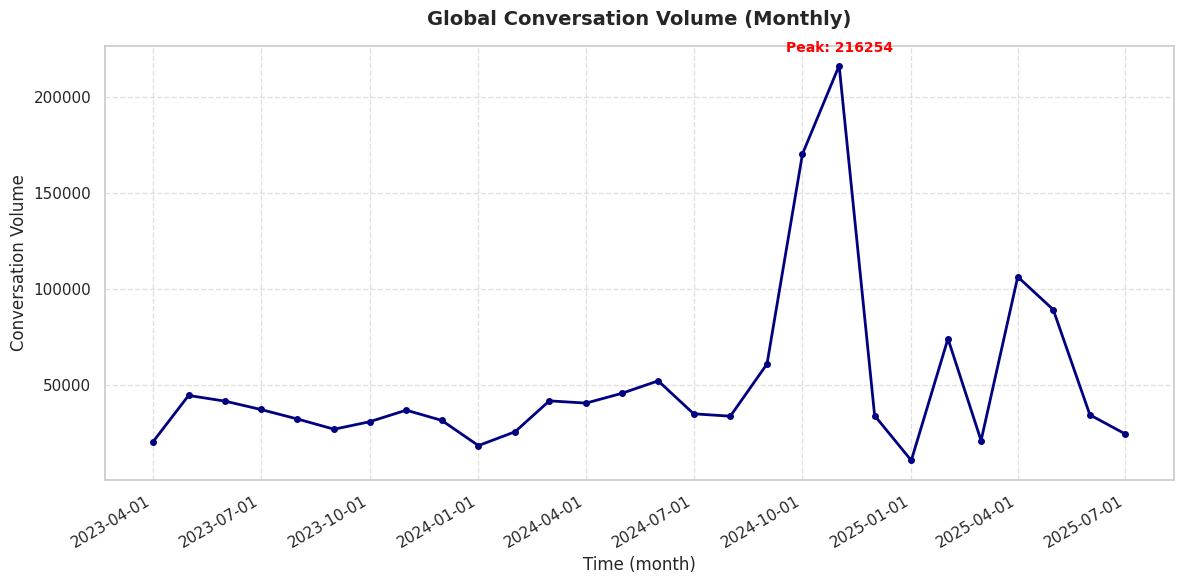

Q2: GPT-4 Adoption Curve (Weekly)


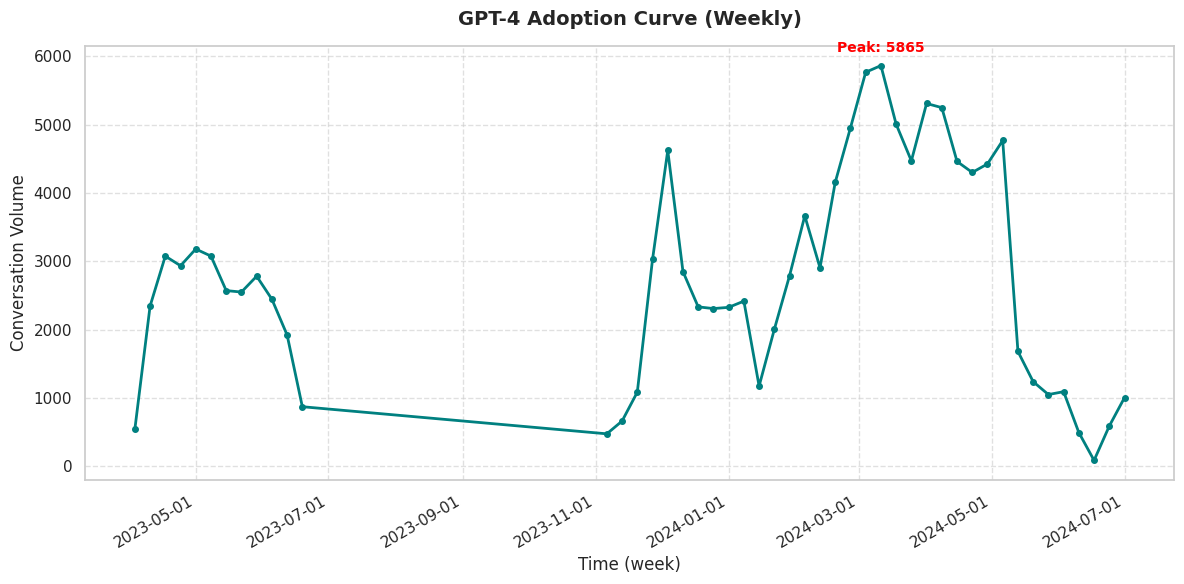

Q3: 'Python' Topic Trend (Monthly)


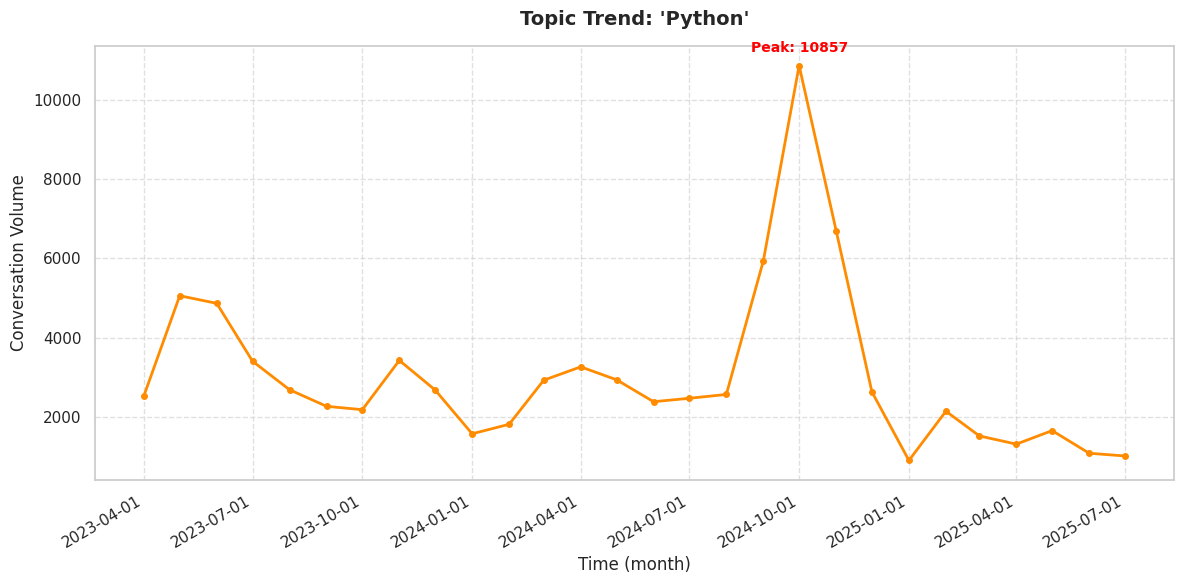

In [55]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_trend_data(json_response: dict, title: str, color: str = '#1f77b4'):
    data = json_response.get('trend_data', [])
    if not data:
        print(f"No data available for plotting: {title}")
        return

    df = pd.DataFrame(data)
    df['period'] = pd.to_datetime(df['period'])
    
    plt.figure(figsize=(12, 6))
    plt.plot(df['period'], df['count'], marker='o', markersize=4, linestyle='-', linewidth=2, color=color)
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel(f"Time ({json_response.get('interval')})", fontsize=12)
    plt.ylabel("Conversation Volume", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gcf().autofmt_xdate() # Rotate dates
    
    max_point = df.loc[df['count'].idxmax()]
    plt.annotate(f"Peak: {max_point['count']}", 
                 xy=(max_point['period'], max_point['count']), 
                 xytext=(0, 10), textcoords='offset points',
                 ha='center', fontsize=10, color='red', fontweight='bold')

    plt.tight_layout()
    plt.show()
    
# [Scenario A] Global Growth Analysis
# Research Question: "What is the overall growth trajectory of the platform?"
# Parameter: interval='month' (Aggregate view)
print("Q1: Overall Monthly Growth Trend")
res_global = get_temporal_trends(interval='month')
print(f"Data Points Found: {len(res_global['trend_data'])}")
plot_trend_data(res_global, "Global Conversation Volume (Monthly)", color='navy')


# [Scenario B] Model Evolution
# Research Question: "Show me the adoption curve for GPT-4."
# Parameter: model='gpt-4', interval='week'
print("Q2: GPT-4 Adoption Curve (Weekly)")
res_gpt4 = get_temporal_trends(interval='week', model='gpt-4')
plot_trend_data(res_gpt4, "GPT-4 Adoption Curve (Weekly)", color='teal')


# [Scenario C] Topic Trend
# Research Question: "Is 'Coding' becoming more popular over time?"
# Parameter: topic='Coding', interval='month'
print("Q3: 'Python' Topic Trend (Monthly)")
res_coding = get_temporal_trends(interval='month', topic='Python')
plot_trend_data(res_coding, "Topic Trend: 'Python'", color='darkorange')

## Discovery Layer

While **Macro Analytics** provides the "Bird's Eye View" (statistics, trends, distributions) and **Micro Inspection** provides the "Street View" (reading individual logs), there remains a critical gap: **Navigation**.

The **Discovery Layer** acts as the bridge between abstract numbers and concrete examples. Its primary purpose is to filter the massive dataset (1.6M+ records) down to a manageable set of relevant samples for qualitative analysis. Without this layer, the Agent would know *that* a trend exists (e.g., "Coding topic spiked in May") but would have no way to understand *why* (e.g., "Users were testing a new Python library").

**Distinction from Other Layers:**
* **vs. Macro:** Macro tools return *Aggregates* (counts, averages). Discovery tools return *Lists of Identifiers & Snippets*.
* **vs. Micro:** Micro tools require a specific `conversation_id` to function. Discovery tools are the mechanism to *find* those IDs based on semantic queries or behavioral patterns.


### 1. Contextual Discovery & Semantic Search (BM25)

Moving beyond aggregate statistics, this section prototypes the core **Discovery** capability. To understand *why* a trend exists or to inspect the quality of specific model responses, we must transition from high-level metrics to the "needle in the haystack." We utilize DuckDB's native Full Text Search (FTS) extension to enable keyword-based retrieval over millions of conversation logs.

**Research Question Addressed:**
Can we efficiently retrieve and inspect conversations regarding specific technical concepts or user intents?
* *Specific Inquiry:* How do users phrase questions about "Segmentation Faults" versus "Memory Leaks"?
* *Data filtering:* Show me long, back-and-forth Math discussions.


In [56]:
def search_conversations(
    query: Optional[str] = None,
    topic: Optional[str] = None,
    model: Optional[str] = None,
    min_turns: Optional[int] = None,
    limit: int = 5
) -> str:
    """
    Search for conversations using keywords (BM25) OR filters (Topic/Model/Length).
    """
    con = get_db_connection()
    try:
        model_list = [model] if model else None
        where_clause, params = _build_filters(model_list, topic, None, None)
        if query:
            # === Mode A: Semantic/Keyword Search (BM25) ===
            # We use the FTS index we built earlier. 
            metadata_filter = where_clause.replace("WHERE", "AND") if where_clause else ""
            
            sql = f"""
                SELECT 
                    id, 
                    model_family,
                    topic,
                    turn_count,
                    fts_main_wildchat.match_bm25(id, ?) AS score,
                    -- Extract a preview snippet (first 200 chars of search_text)
                    substr(search_text, 1, 200) as snippet
                FROM wildchat
                WHERE score IS NOT NULL
                {metadata_filter}
            """
            if min_turns:
                sql += f" AND turn_count >= {min_turns}"
            sql += " ORDER BY score DESC LIMIT ?"
            query_params = [query] + params + [limit]
            
        else:
            # === Mode B: Pure Metadata Filtering ===
            # No keyword provided; retrieving recent or random examples matching criteria.
            
            sql = f"""
                SELECT 
                    id, 
                    model_family, 
                    topic, 
                    turn_count,
                    0 as score,
                    substr(search_text, 1, 200) as snippet
                FROM wildchat
                {where_clause}
            """
            if min_turns:
                connector = "AND" if where_clause else "WHERE"
                sql += f" {connector} turn_count >= {min_turns}"
            sql += " ORDER BY timestamp DESC LIMIT ?"
            query_params = params + [limit]
        df = con.execute(sql, query_params).fetchdf()
        if df.empty:
            return "No conversations found matching criteria."
            
        return df.to_dict(orient='records')

    except Exception as e:
        return f"Error searching conversations: {str(e)}"
    finally:
        con.close()

In [59]:
# [Scenario A] Semantic Concept Retrieval
# Use Case: "Find me examples of segmentation faults."
results_a = search_conversations(query="segmentation fault", limit=3)

if isinstance(results_a, list) and results_a:
    for idx, item in enumerate(results_a):
        print(f"[{idx+1}] ID: {item['id'][:8]}... | Score: {item['score']:.2f}")
        print(f"    Snippet: {item['snippet'].replace(chr(10), ' ')[:80]}...")
else:
    print(f"Result: {results_a}")  

print("\n" + "-"*40 + "\n")

# [Scenario B] Deep Dive Discovery (No Keywords)
# Use Case: "Show me long, back-and-forth Math discussions."
results_b = search_conversations(
    topic="Writing", 
    min_turns=5, 
    limit=3
)

if isinstance(results_b, list) and results_b:
    for item in results_b:
        print(f"Deep Conv Found | Turns: {item['turn_count']}")
        print(f"    Snippet: {item['snippet'].replace(chr(10), ' ')[:80]}...")

[1] ID: 7f868e95... | Score: 7.12
    Snippet: 26287 segmentation fault 当我运行我的python代码时，报这个错：26287 segmentation fault 当我运行我的pyt...
[2] ID: 9a93ce83... | Score: 6.99
    Snippet: Hi,I tried to build the MSYS2 Package mingw-w64-i686-python-3 for 32bit (MINGW_A...
[3] ID: 83cc40d7... | Score: 6.98
    Snippet: You are a helpful assistant generating synthetic data that captures *System 1* a...

----------------------------------------

Deep Conv Found | Turns: 8
    Snippet: Hypothetical: Ru Paul Comedy segement, they symbolicly 'cook' a "turkey" (losing...
Deep Conv Found | Turns: 6
    Snippet: CITV March 2006 Schedule on March 11 2006, CITV offically launched as a channel,...
Deep Conv Found | Turns: 6
    Snippet: CITV March 2006 Schedule on March 11 2006, CITV offically launched as a channel,...


### 2. User Behavioral Segmentation

While topic analysis tells us *what* is being discussed, it does not explain *who* is discussing it. Understanding user behavior is critical for identifying "Power Users" (who drive the majority of traffic) and "Specialists" (who rely on the model for specific professional workflows). This tool aggregates interaction patterns by anonymized identifiers (`hashed_ip`) to reveal high-level usage archetypes.

**Research Questions Addressed:**

1.  **Power User Identification (Pareto Principle):**
    * *Inquiry:* Does a small percentage of users generate the majority of the traffic? What topics drive the highest engagement for these top users?
2.  **Usage Diversity (Generalist vs. Specialist):**
    * *Inquiry:* Do users treat the LLM as a "Chatbot for Everything" (Generalists) or a "Specialized Tool" (Specialists)?
    * *Metric:* Analyzed via the **Topic Diversity Ratio** ($\frac{Distinct Topics}{Total Conversations}$).


In [60]:
def analyze_user_behavior(
    behavior_type: Literal["power_users", "topic_consistency"] = "power_users",
    limit: int = 10
) -> str:
    """
    Analyzes user engagement patterns based on hashed IPs.
    """
    con = get_db_connection()
    try:
        base_filter = "topic IS NOT NULL AND topic != 'General / Noise'"
        
        if behavior_type == "power_users":
            query = f"""
                SELECT 
                    hashed_ip,
                    COUNT(*) as total_convos,
                    mode(topic) as favorite_topic, -- Most frequent meaningful topic
                    CAST(AVG(turn_count) AS INTEGER) as avg_turns
                FROM wildchat
                WHERE {base_filter}
                GROUP BY hashed_ip
                ORDER BY total_convos DESC
                LIMIT ?
            """
        
        elif behavior_type == "topic_consistency":
            query = f"""
                SELECT 
                    hashed_ip,
                    COUNT(*) as total_convos,
                    COUNT(DISTINCT topic) as distinct_topics,
                    mode(topic) as main_interest
                FROM wildchat
                WHERE {base_filter}
                GROUP BY hashed_ip
                HAVING total_convos > 10 -- Only analyze recurring users to ensure statistical significance
                ORDER BY (CAST(distinct_topics AS FLOAT) / total_convos) ASC -- Low ratio = Specialist
                LIMIT ?
            """
        
        df = con.execute(query, [limit]).fetchdf()
        return df.to_dict(orient='records')

    except Exception as e:
        return f"Error analyzing behavior: {str(e)}"
    finally:
        con.close()

In [62]:
# [Scenario A] Power User Profiling
# Research Question: "Who are the heaviest users of the platform, and what do they care about?"
res_power = analyze_user_behavior(behavior_type="power_users", limit=5)

if res_power:
    for rank, user in enumerate(res_power):
        # Masking IP for display, showing behavioral metrics
        short_ip = user['hashed_ip'][:8]
        print(f"#{rank+1} [User {short_ip}...] | Convos: {user['total_convos']} | Fav Topic: {user['favorite_topic']} (Avg Turns: {user['avg_turns']})")
else:
    print("No power users found.")

print("\n" + "-"*40 + "\n")


# [Scenario B] Specialist Identification
# Research Question: "Can we find users who use the tool exclusively for one purpose?"
# Hypothesis: We expect to see users with high conversation counts but very low 'distinct_topics'.
res_specialists = analyze_user_behavior(behavior_type="topic_consistency", limit=5)

if res_specialists:
    for user in res_specialists:
        short_ip = user['hashed_ip'][:8]
        diversity_ratio = user['distinct_topics'] / user['total_convos']
        print(f"[User {short_ip}...] | Topics: {user['distinct_topics']}/{user['total_convos']} (Ratio: {diversity_ratio:.2f}) | Main Interest: {user['main_interest']}")
else:
    print("No specialists found.")

#1 [User 0ebf3dbb...] | Convos: 39163 | Fav Topic: Web Dev (Avg Turns: 1)
#2 [User ab8d1faf...] | Convos: 19141 | Fav Topic: User Queries (Avg Turns: 1)
#3 [User 25fe0280...] | Convos: 6290 | Fav Topic: User Queries (Avg Turns: 1)
#4 [User 2a28eab6...] | Convos: 5944 | Fav Topic: Python (Avg Turns: 3)
#5 [User ce889ce3...] | Convos: 5716 | Fav Topic: Genomic Models (Avg Turns: 1)

----------------------------------------

[User 513481c2...] | Topics: 1/1158 (Ratio: 0.00) | Main Interest: User Queries
[User 0ebf3dbb...] | Topics: 36/39163 (Ratio: 0.00) | Main Interest: Web Dev
[User 30b7c43e...] | Topics: 1/866 (Ratio: 0.00) | Main Interest: User Queries
[User 9e1c1bd2...] | Topics: 6/4660 (Ratio: 0.00) | Main Interest: Writing Prompt
[User 50d2cdeb...] | Topics: 2/1123 (Ratio: 0.00) | Main Interest: Prompt Generation


### 3. Anomaly Detection & Outlier Discovery

While standard analysis focuses on the "average" user behavior, some of the most critical insights lie at the extremes. Whether it is an excessively long reasoning chain (potentially indicating a "jailbreak" attempt or a complex roleplay) or a hyper-specific topic (indicating a niche hallucination), identifying outliers is crucial for safety auditing and edge-case analysis.

**Research Questions Addressed:**

1.  **Structural Anomalies (Length Outliers):**
    * *Inquiry:* Are there conversations that significantly deviate from the norm in terms of length? Do these correlate with specific models (e.g., O1 reasoning chains) or adversarial user behaviors?
    * *Mechanism:* Filters for conversations where $TurnCount > Threshold \times Average$.

2.  **Semantic Anomalies (Rare Topics):**
    * *Inquiry:* What topics appear so infrequently ($N < 50$) that they might represent edge cases, privacy leaks, or hallucinations?
    * *Mechanism:* Filters for topics in the "Long Tail" of the distribution.


In [64]:
def detect_conversation_anomalies(
    anomaly_type: Literal["length_outlier", "rare_topic"] = "length_outlier",
    model: Optional[str] = None,
    threshold: float = 10.0
) -> str:
    """
    Finds specific anomalous conversations for inspection.
    """
    con = get_db_connection()
    try:
        model_list = [model] if model else None
        where_clause, params = _build_filters(model_list, None, None, None)
        
        if anomaly_type == "length_outlier":
            # 1. Calculate Baseline (Dynamic Average)
            avg_query = f"SELECT AVG(turn_count) FROM wildchat {where_clause}"
            avg_turns = con.execute(avg_query, params).fetchone()[0] or 0
            
            # 2. Find Outliers (Benchmark * Threshold)
            target = avg_turns * threshold
            
            query = f"""
                SELECT 
                    id, 
                    model_family, 
                    turn_count as metric_value,
                    {int(avg_turns)} as avg_benchmark,
                    substr(search_text, 1, 100) as snippet
                FROM wildchat
                {where_clause} 
                {'AND' if where_clause else 'WHERE'} turn_count > ?
                ORDER BY turn_count DESC
                LIMIT 5
            """
            params.append(target)
            
        elif anomaly_type == "rare_topic":
            # Find topics with very few conversations (Potential hallucinations or niche attacks)
            query = f"""
                WITH RareTopics AS (
                    SELECT topic 
                    FROM wildchat 
                    GROUP BY topic 
                    HAVING COUNT(*) < 50
                )
                SELECT 
                    id, model_family, topic, substr(search_text, 1, 100) as snippet
                FROM wildchat
                WHERE topic IN (SELECT topic FROM RareTopics)
                LIMIT 5
            """
            
        else:
            return "Error: Unknown anomaly type."

        df = con.execute(query, params).fetchdf()
        
        if df.empty:
            return f"No anomalies found. (Avg Turns was {avg_turns:.1f}, Threshold was {threshold}x)"
            
        return df.to_dict(orient='records')

    except Exception as e:
        return f"Error detecting anomalies: {str(e)}"
    finally:
        con.close()

In [70]:
print("--- Starting Anomaly Detection Analysis ---\n")

# [Scenario A] Extreme Length Detection
# Research Question: "Find the absolute longest conversations. Are they roleplays or bugs?"
# Threshold: 20x the average length (Very strict)
print("Q1: Extreme Length Outliers (>20x Avg)")
res_len = detect_conversation_anomalies(
    anomaly_type="length_outlier", 
    threshold=20.0
)

if isinstance(res_len, list):
    for item in res_len:
        print(f"[ID: {item['id']}] | Turns: {item['metric_value']} (Avg: {item['avg_benchmark']})")
        print(f"   Snippet: {item['snippet'][:80]}...")
else:
    print(res_len) # Print error or "No found" message

print("\n" + "-"*40 + "\n")


# [Scenario B] Model-Specific Outliers
# Research Question: "Does GPT-4 have exceptionally long conversations compared to its OWN average?"
# Threshold: 10x the GPT-4 average
print("Q2: GPT-4 Specific Outliers (>10x Avg)")
res_gpt4 = detect_conversation_anomalies(
    anomaly_type="length_outlier", 
    model="gpt-4", 
    threshold=10.0
)

if isinstance(res_gpt4, list):
    print(f"Found {len(res_gpt4)} outliers for GPT-4.")
    top_outlier = res_gpt4[0]
    print(f"Top Outlier: {top_outlier['metric_value']} turns. (GPT-4 Avg: {top_outlier['avg_benchmark']})")
else:
    print(res_gpt4)

print("\n" + "-"*40 + "\n")


# [Scenario C] Rare Topic Discovery
# Research Question: "What are the weirdest, least discussed topics?"
print("Q3: Rare Topic Discovery (N < 50)")
res_rare = detect_conversation_anomalies(anomaly_type="rare_topic")

if isinstance(res_rare, list):
    for item in res_rare:
        print(f"Topic: '{item['topic']}' | Model: {item['model_family']}")
        print(f"   Snippet: {item['snippet'][:80]}...")
else:
    print(res_rare)

--- Starting Anomaly Detection Analysis ---

Q1: Extreme Length Outliers (>20x Avg)
[ID: b88e367f039684b523f8ad68535f0e58] | Turns: 350 (Avg: 1)
   Snippet: no, if you! no, if you! no, if you! no, if you! no, if you! no, if you! no, if y...
[ID: 16380a0394092ec2619b808f8ba42521] | Turns: 220 (Avg: 1)
   Snippet: The horizontal axis represents time (seconds) ranging from 0 through 10 in incre...
[ID: 9826301d478d359ea3abf2aae1e88bfc] | Turns: 201 (Avg: 1)
   Snippet: we are building a system together, i want to share with you our whole conversati...
[ID: 8b1d551afd8ca512b812184b05734d50] | Turns: 193 (Avg: 1)
   Snippet: I want you to create a detailed name for the microstock image. When provided wit...
[ID: 16c99a128ed918d2ed9d763b21e86f22] | Turns: 175 (Avg: 1)
   Snippet: Question Mode Fill in the Blank Question Fill in the blank question. For work to...

----------------------------------------

Q2: GPT-4 Specific Outliers (>10x Avg)
Found 5 outliers for GPT-4.
Top Outlier: 147 turn

## Micro-Inspection

Finally, once a relevant conversation ID is found via Search or Anomaly Detection, the agent needs to retrieve the full content. This corresponds to the **MCP Resource** primitive.

**The Strategic Purpose:**
While Macro analysis provides the "Map" and Discovery provides the "Coordinates," Micro-Inspection is the act of "Walking the Territory." It is the layer of **Ground Truth**. Without this layer, the analysis remains theoretical. We need this layer to validate hypotheses formed in the previous steps (e.g., "Is this long conversation actually a jailbreak, or just a long creative writing prompt?").

**Research Objectives:**
1.  **Qualitative Analysis:** Reading the actual dialogue to understand user intent, tone, frustration, or satisfaction.
2.  **Safety & Compliance:** Verifying if a model's refusal was correct or if a safety guardrail was bypassed.
3.  **Contextual Verification:** Ensuring that the high-level topic classification (e.g., "Coding") was accurate for this specific instance.


In [75]:
def get_conversation_content(conversation_id: str) -> str:
    """
    Retrieves the FULL content of a specific conversation by ID.
    """
    con = get_db_connection()
    try:
        result = con.execute(
            "SELECT search_text, full_content, model, topic FROM wildchat WHERE id = ?", 
            [conversation_id]
        ).fetchone()
        
        if not result:
            return "Error: Conversation ID not found."
        search_text, content_json, model, topic = result
        messages = json.loads(content_json)
        
        response = {
            "id": conversation_id,
            "metadata": {"model": model, "topic": topic, "turn_count": len(messages)},
            "search_text": search_text,
            "conversation": messages
        }
        
        return response
        
    except Exception as e:
        return f"Error retrieving conversation: {str(e)}"
    finally:
        con.close()

In [76]:
# [Scenario] Get a real ID from DB (so the test actually works)
sample_id = 'b88e367f039684b523f8ad68535f0e58'
res_content = get_conversation_content(sample_id)

if "error" not in res_content:
    meta = res_content['metadata']
    print(f"Metadata: Model={meta['model']} | Topic={meta['topic']} | Turns={meta['turn_count']}")
    user_input = res_content['search_text']
    print(f"First User Message: {user_input[:100]}...")
else:
    print(res_content)


Metadata: Model=gpt-4o-mini-2024-07-18 | Topic=General | Turns=700
First User Message: no, if you! no, if you! no, if you! no, if you! no, if you! no, if you! no, if you! no, if you! no, ...


## Advanced Analysis: Ad-Hoc SQL Execution

While the Macro, Discovery, and Micro layers cover 90% of standard analytical workflows, there remains unanticipated questions that pre-defined Python functions cannot address. To solve this, we introduce an **Ad-Hoc SQL Tool** that empowers the LLM to write and execute its own queries.

**The Strategic Purpose:**
This tool represents the highest level of agentic autonomy. It allows the agent to bypass the limitations of hardcoded logic and interact directly with the data substrate.

**Capabilities**
1.  **Complex Logic:** "Find conversations where the user *started* with English but *switched* to Chinese halfway through." (Requires string manipulation not available in standard tools).
3.  **Cross-Table Joins:** If we eventually add a `users` or `feedback` table, only SQL can join them dynamically.

**Safety & Constraints (The "Sandbox"):**
Granting an LLM direct database access carries risk. We implement a strict **Read-Only Sandbox**:
* **Permissions:** The connection is instantiated in `read_only` mode.
* **Keyword Banning:** Explicitly blocks `DROP`, `DELETE`, `INSERT`, `UPDATE`.
* **Context Protection:** Enforces a hard limit (Max 20 rows) to prevent context window overflow.


In [77]:
def run_sql_query(query: str) -> str:
    """
    Executes a raw SQL query against the WildChat database.

    """
    con = duckdb.connect(DB_PATH, read_only=True)
    
    try:
        forbidden_keywords = ["DROP", "DELETE", "INSERT", "UPDATE", "ALTER", "TRUNCATE"]
        if any(k in query.upper() for k in forbidden_keywords):
            return "Error: Write operations are strictly forbidden."

        df = con.execute(query).fetchdf()
        
        if len(df) > 20:
            df = df.head(20)
            warning = f"\n(Note: Result truncated. Showing top 20 of {len(df)} rows. Use LIMIT in SQL to refine.)"
        else:
            warning = ""
            
        return df.to_json(orient='records', date_format='iso') + warning

    except Exception as e:
        return f"SQL Execution Error: {str(e)}"
    finally:
        con.close()

In [83]:
# [Scenario A] Complex Filtering 
# Problem: User wants a specific intersection: "Python" topic + "GPT-4" model + "More than 20 turns".
complex_sql = """
    SELECT id, turn_count, substr(search_text, 1, 50) as snippet
    FROM wildchat
    WHERE topic = 'Python' 
      AND model_family LIKE '%gpt-4%' 
      AND turn_count > 20
    ORDER BY turn_count DESC
    LIMIT 3
"""
res_complex = json.loads(run_sql_query(complex_sql))

if isinstance(res_complex, list) and res_complex:
    for item in res_complex:
        print(f"Match: {item['id'][:8]}... | Turns: {item['turn_count']} | Snippet: {item['snippet']}...")
else:
    print("No matches found for this complex criteria.")

print("\n" + "-"*40 + "\n")


# [Scenario B] Safety Protocol Verification
# Situation: An adversarial user (or hallucinating LLM) tries to delete data.
malicious_sql = "DROP TABLE wildchat"
res_security = run_sql_query(malicious_sql)
print(f"System Response: {res_security}")


Match: 7ca4ae89... | Turns: 147 | Snippet: let us play a game. I am thinking of a science fic...
Match: 0fea2dc0... | Turns: 144 | Snippet: hi residential isp name on london? vodafone three ...
Match: 7fa05718... | Turns: 107 | Snippet: Testing Which statement best describes the domain ...

----------------------------------------

System Response: Error: Write operations are strictly forbidden.
